# Defensive line -- distance from goal (with real clips and 2D animations)

Built on the Step 1 tables (`player_frame_table_named`, `ball_frame_table_named`, `match_meta_named.json`).
No names are used: the back line of each team is **inferred** from average positions in possession.

Per frame and team:
- **line height** = mean distance from own goal (`x_att`) of the visible back-line players (>= 3 visible)
- **last defender** (offside line) = the deepest outfield player
- **flatness** (spread of the back line in depth), **width**, **goalkeeper -> line** and **line -> midfield** distances,
  ball position seen from the defending team

Then: team summary in / out of possession and per block, **line height vs ball position** (how the line steps up and
drops), a timeline over the half, **drop / step-up events** (line retreats or pushes >= 8 m in 2 s), a per-defender
table (average depth, share as last defender), and automatically chosen moments as
**real match clips** (the line and offside line drawn on the grass, back line highlighted, live line-height graph,
mini-pitch) and **2D animations** (top-down pitch + line-height timeline with a moving cursor).

Single camera: line metrics are only computed in frames where >= 3 of the back-line players are visible.

In [13]:
import os, io, json, pickle
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.patches import Rectangle

CACHE_DIR = r"C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache"
VIDEO_PATH = r"C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\clip.mkv"
PLAYER_TABLE = os.path.join(CACHE_DIR, "player_frame_table_named.parquet")
BALL_TABLE   = os.path.join(CACHE_DIR, "ball_frame_table_named.parquet")
META_PATH    = os.path.join(CACHE_DIR, "match_meta_named.json")
HOMOGRAPHY_PATH = os.path.join(CACHE_DIR, "homography_cache_barca_atletico_firsthalf.pkl")
OUT_DIR  = os.path.join(CACHE_DIR, "defensive_line")
CLIP_DIR = os.path.join(OUT_DIR, "clips")
ANIM_DIR = os.path.join(OUT_DIR, "animations")

TEAM_COLORS = {"BAR": (152, 77, 0), "ATM": (36, 53, 203)}     # BGR (clips); figures use the same colours
LINE_GAP_M = 5.0                 # line detection from average depths (same rule as the pressing-structure notebook)
MIN_DEF_VISIBLE = 3              # line height only when >= 3 back-line players are on screen
SMOOTH_FRAMES = 13               # rolling median for events / timeline
EVENT_WINDOW_S = 2.0             # drop / step-up = line moves >= EVENT_MIN_M within 2 s
EVENT_MIN_M = 8.0
EVENT_SEPARATION_S = 5.0
CLIP_PRE_S, CLIP_POST_S = 3.0, 3.0
RENDER_CLIPS, RENDER_ANIMATIONS = True, True
ANIM_STEP = 2                    # 2D animation uses every 2nd frame (12.5 fps)
PX_PER_METER = 10.0

for d in (OUT_DIR, CLIP_DIR, ANIM_DIR):
    os.makedirs(d, exist_ok=True)
pf = pd.read_parquet(PLAYER_TABLE)
bt = pd.read_parquet(BALL_TABLE).set_index("frame_idx").sort_index()
meta = json.load(open(META_PATH, encoding="utf-8"))
FPS, L, W, N_FRAMES = meta["fps"], meta["pitch_length"], meta["pitch_width"], meta["n_frames"]
TEAM_NAMES = {int(k): v for k, v in meta["team_names"].items()}
ATTACK_DIR = {int(k): v for k, v in meta["attack_dir"].items()}
PEOPLE = {int(k): v for k, v in meta["people"].items()}
NUM = {t: v["number"] for t, v in PEOPLE.items()}
LABEL = {t: f"{v['team_name'] or ''} {v['number'] if v['number'] is not None else ''} {v['name']}".strip() for t, v in PEOPLE.items()}
RGB = {nm: tuple(c / 255 for c in col[::-1]) for nm, col in TEAM_COLORS.items()}


def along_x(x, team): return x if ATTACK_DIR[team] == 1 else L - x
def along_y(y, team): return y if ATTACK_DIR[team] == 1 else W - y
def to_pitch_x(x_att, team): return x_att if ATTACK_DIR[team] == 1 else L - x_att
def mmss(f): return f"{int(f / FPS // 60):02d}:{f / FPS % 60:04.1f}"


live = pf[~pf.is_stoppage & pf.pitch_x.notna()].copy()
live["y_att"] = np.where(live.attack_dir.astype(float) == 1, live.pitch_y, W - live.pitch_y)
print(f"live rows {len(live):,} | teams {TEAM_NAMES} | attack dir {ATTACK_DIR}")

live rows 1,362,375 | teams {0: 'ATM', 1: 'BAR'} | attack dir {0: -1, 1: 1}


## 1. Back line of each team (inferred from average positions in possession)

In [14]:
def split_lines(depths, gap=LINE_GAP_M):
    order = np.argsort(depths); d = np.asarray(depths)[order]; gaps = np.diff(d); cut = []
    for rank, c in enumerate(np.argsort(gaps)[::-1][:3]):
        if gaps[c] > (gap if rank < 2 else 1.6 * gap):
            cut.append(int(c))
    if not cut and len(gaps):
        cut = [int(np.argmax(gaps))]
    lines, start = [], 0
    for c in sorted(cut):
        lines.append(list(order[start:c + 1])); start = c + 1
    lines.append(list(order[start:]))
    return lines


# ---- Section 1: back line of each team = the deepest outfield players on average OUT of possession ----
# (in possession the full-backs push up, so the back line is read from the defending shape)
BACK_LINE_N = 4      # 4 = back four (3 or 5 for a back three / five)
MID_LINE_N = 4       # the next players by depth = midfield line (for the line -> midfield gap)

DEF, MID, GK = {}, {}, {}
for k, nm in TEAM_NAMES.items():
    t = live[live.team == k]
    defending = t[(t.possession_team.notna() & (t.possession_team != k)).fillna(False)]
    src = defending if defending.frame_idx.nunique() >= 60 * FPS else t      # fall back to all frames if too little
    g = src.groupby("track_id").agg(role=("role", "first"), x=("x_att", "mean"), y=("y_att", "mean"),
                                    n=("frame_idx", "size"))
    g = g[g.n >= 5 * FPS]
    out = g[g.role == "player"].sort_values("x")
    DEF[k] = [int(i) for i in out.index[:BACK_LINE_N]]
    MID[k] = [int(i) for i in out.index[BACK_LINE_N:BACK_LINE_N + MID_LINE_N]]
    GK[k] = [int(i) for i in g[g.role == "goalkeeper"].index]
    print(f"{nm}: back line -> " + ", ".join(f"{LABEL[i]} ({out.loc[i, 'x']:.1f} m)"
                                             for i in sorted(DEF[k], key=lambda i: out.loc[i, 'y'])))
    print(f"   midfield line -> " + ", ".join(LABEL[i] for i in MID[k]))
    vis = t[t.track_id.isin(DEF[k])].groupby("frame_idx").size()
    print(f"   frames with >= {MIN_DEF_VISIBLE} back-line players visible: {(vis >= MIN_DEF_VISIBLE).sum() / FPS / 60:.1f} min "
          f"(of {t.frame_idx.nunique() / FPS / 60:.1f} min with the team on screen)")

ATM: back line -> ATM 21 Javi Galan (30.5 m), ATM 15 Lenglet (27.6 m), ATM 2 Gimenez (28.8 m), ATM 14 Llorente (30.0 m)
   midfield line -> ATM 8 Barrios, ATM 5 De Paul, ATM 4 Gallagher, ATM 22 Simeone
   frames with >= 3 back-line players visible: 39.1 min (of 39.6 min with the team on screen)
BAR: back line -> BAR 3 Balde (49.4 m), BAR 5 Inigo (45.3 m), BAR 2 Cubarsi (45.4 m), BAR 23 Kounde (51.6 m)
   midfield line -> BAR 17 Casado, BAR 8 Pedri, BAR 6 Gavi, BAR 16 Fermin
   frames with >= 3 back-line players visible: 38.5 min (of 39.6 min with the team on screen)


## 2. Per-frame line metrics

In [ ]:
# ---- Section 2: per-frame line metrics (corners removed, back line must be the last line) ----
# line_x = distance from own goal of the LAST (deepest) back-line defender; line_mean_x = mean of the back line
CORNER_GAP_S = 3.0           # ball dead >= 3 s before the restart
CORNER_ZONE_M = 6.0          # restart taken within 6 m of a corner flag = corner
CORNER_PHASE_S = 10.0        # frames up to 10 s after the corner kick are removed
REQUIRE_BACK_LINE_LAST = True

bx = bt.ball_pitch_x.reindex(range(N_FRAMES)).values
by = bt.ball_pitch_y.reindex(range(N_FRAMES)).values
poss = bt.possession_team.astype("float").reindex(range(N_FRAMES)).values
carr = bt.carrier_track_id.astype("float").reindex(range(N_FRAMES)).values

# ---- corners ----
has = ~np.isnan(carr)
corner_mask = np.zeros(N_FRAMES, dtype=bool)
CORNERS = []
for f in np.where(has[1:] & ~has[:-1])[0] + 1:
    b = f - 1
    while b >= 0 and not has[b]:
        b -= 1
    if (f - b - 1) < CORNER_GAP_S * FPS:
        continue
    xy = next(((bx[j], by[j]) for j in range(f, min(f + 6, N_FRAMES)) if np.isfinite(bx[j])), None)
    if xy is None:
        r = live[(live.frame_idx == f) & (live.track_id == int(carr[f]))]
        xy = (r.pitch_x.iloc[0], r.pitch_y.iloc[0]) if len(r) else None
    if xy is None:
        continue
    near_x = xy[0] <= CORNER_ZONE_M or xy[0] >= L - CORNER_ZONE_M
    near_y = xy[1] <= CORNER_ZONE_M or xy[1] >= W - CORNER_ZONE_M
    if near_x and near_y:
        e = min(N_FRAMES - 1, f + int(CORNER_PHASE_S * FPS))
        corner_mask[b + 1:e + 1] = True
        CORNERS.append({"kick_frame": int(f), "time": mmss(f), "excluded_from": int(b + 1), "excluded_to": int(e),
                        "taken_by": TEAM_NAMES.get(int(poss[f])) if np.isfinite(poss[f]) else None})
print(f"corners found: {len(CORNERS)} -> {corner_mask.sum() / FPS:.0f} s removed")
for c in CORNERS:
    print(f"   {c['time']}  corner for {c['taken_by']}")

# ---- line metrics per frame ----
recs = []
for k, nm in TEAM_NAMES.items():
    t = live[live.team == k]
    d = t[t.track_id.isin(DEF[k])].groupby("frame_idx").agg(n_def=("x_att", "size"), line_mean_x=("x_att", "mean"),
                                                           line_x=("x_att", "min"),          # line height = LAST defender
                                                           flatness=("x_att", "std"), y_min=("y_att", "min"), y_max=("y_att", "max"))
    deep = t[t.role == "player"].sort_values("x_att").groupby("frame_idx").head(1).set_index("frame_idx")
    m = t[t.track_id.isin(MID[k])].groupby("frame_idx").x_att.mean().rename("mid_x")
    g = t[t.track_id.isin(GK[k])].groupby("frame_idx").x_att.mean().rename("gk_x")
    df = d.join([deep.x_att.rename("last_defender_x"), deep.track_id.rename("last_defender_id"), m, g])
    df["width"] = df.y_max - df.y_min
    df["team"], df["team_name"] = k, nm
    df["last_is_back_line"] = df.last_defender_id.isin(DEF[k])
    recs.append(df.reset_index())
LH = pd.concat(recs, ignore_index=True)
n0 = len(LH)
keep = LH.n_def >= MIN_DEF_VISIBLE
n_vis = int((~keep).sum())
in_corner = corner_mask[LH.frame_idx.values]
n_cor = int((keep & in_corner).sum())
keep &= ~in_corner
if REQUIRE_BACK_LINE_LAST:
    n_last = int((keep & ~LH.last_is_back_line).sum())
    keep &= LH.last_is_back_line
else:
    n_last = 0
LH = LH[keep].copy()
print(f"team-frames: {n0:,} -> {len(LH):,} kept | removed: < {MIN_DEF_VISIBLE} back-line players visible {n_vis:,}, "
      f"corners {n_cor:,}, deepest player not a defender {n_last:,}")

LH["ball_x_att"] = [along_x(bx[f], k) if np.isfinite(bx[f]) else np.nan for f, k in zip(LH.frame_idx, LH.team)]
p_ = poss[LH.frame_idx.values]
LH["phase"] = np.where(np.isnan(p_), "no_possession", np.where(p_ == LH.team.values, "in_possession", "out_of_possession"))
LH["block"] = np.select([LH.ball_x_att >= 70, LH.ball_x_att >= 35, LH.ball_x_att < 35], ["high", "mid", "low"], None)
LH["gk_to_line_m"] = LH.line_x - LH.gk_x
LH["line_to_mid_m"] = LH.mid_x - LH.line_x
LH = LH.sort_values(["team", "frame_idx"]).reset_index(drop=True)
LH["line_x_smooth"] = LH.groupby("team").line_x.transform(lambda s: s.rolling(SMOOTH_FRAMES, center=True, min_periods=3).median())
print("frames with a measurable line: " + ", ".join(f"{nm} {(LH.team == k).sum() / FPS / 60:.1f} min"
                                                    for k, nm in TEAM_NAMES.items()))

frames with a measurable line: ATM 39.1 min, BAR 38.5 min


## 3. Team summary

In [16]:
def q(s): return f"{s.median():.1f} ({s.quantile(.25):.1f}-{s.quantile(.75):.1f})" if len(s) else "-"


rows = []
for (nm, ph), g in LH[LH.phase != "no_possession"].groupby(["team_name", "phase"]):
    rows.append({"team": nm, "phase": ph, "minutes": round(len(g) / FPS / 60, 1),
                 "line height m, median (IQR)": q(g.line_x), "last defender m": q(g.last_defender_x),
                 "flatness m": round(g.flatness.median(), 1), "width m": round(g.width.median(), 1),
                 "GK -> line m": round(g.gk_to_line_m.median(), 1), "line -> midfield m": round(g.line_to_mid_m.median(), 1)})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
blk = LH[LH.phase == "out_of_possession"].groupby(["team_name", "block"]).line_x.agg(["median", "size"])
blk["minutes"] = (blk["size"] / FPS / 60).round(1)
print("\nout of possession, by where the ball is:\n", blk[["median", "minutes"]].round(1).to_string())

team             phase  minutes line height m, median (IQR)  last defender m  flatness m  width m  GK -> line m  line -> midfield m
 ATM     in_possession     14.8            30.2 (17.4-46.7) 23.8 (11.2-38.6)         7.0     40.5          14.5                12.1
 ATM out_of_possession     21.0            26.1 (18.2-40.2) 23.5 (16.6-37.5)         2.0     32.7          15.3                 8.7
 BAR     in_possession     20.8            56.4 (40.2-66.6) 49.9 (33.9-58.3)         7.1     42.1          15.9                12.1
 BAR out_of_possession     14.4            49.7 (38.1-58.2) 47.3 (35.6-51.8)         3.6     32.7          19.1                11.5

out of possession, by where the ball is:
                  median  minutes
team_name block                 
ATM       high     47.8      3.9
          low      16.3      6.5
          mid      28.8      9.1
BAR       high     57.7      6.2
          low      17.9      2.0
          mid      42.6      4.5


## 4. Figures: distribution, line height vs ball position, timeline

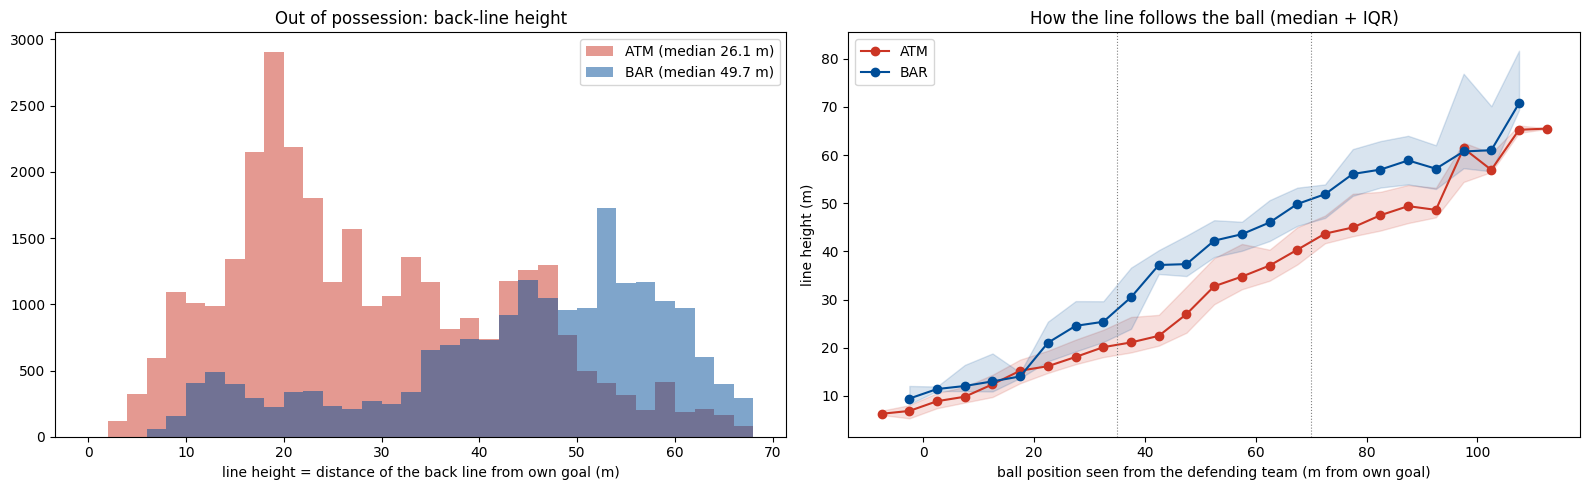

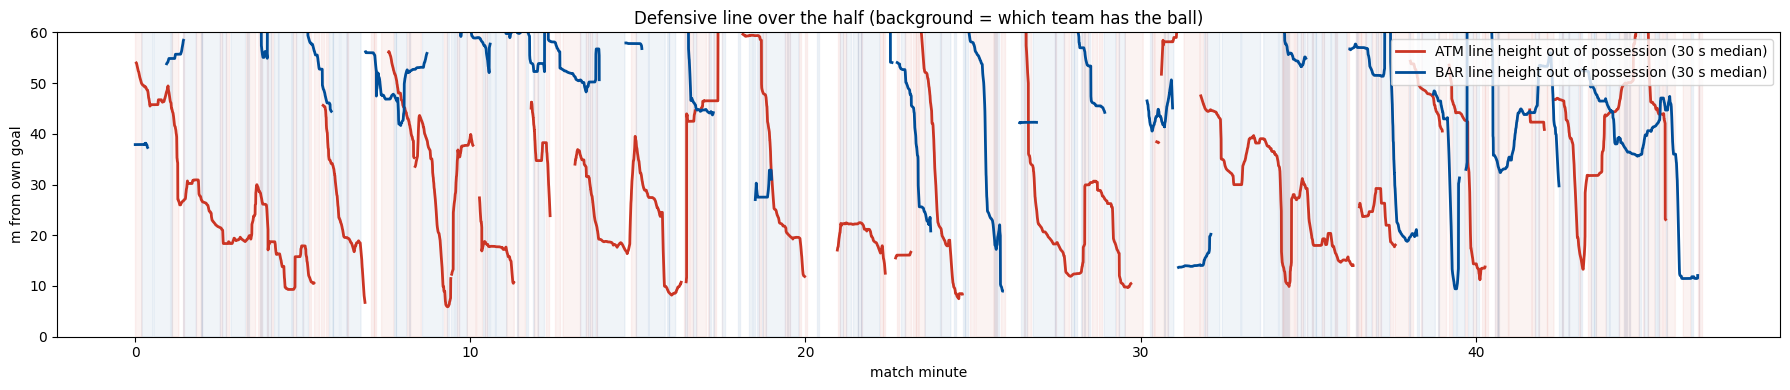

In [17]:
oop = LH[LH.phase == "out_of_possession"]
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
for nm in TEAM_NAMES.values():
    s = oop[oop.team_name == nm].line_x
    axs[0].hist(s, bins=np.arange(0, 70, 2), alpha=0.5, color=RGB.get(nm), label=f"{nm} (median {s.median():.1f} m)")
    g = oop[oop.team_name == nm].assign(bin=(oop.ball_x_att // 5) * 5 + 2.5).groupby("bin").line_x
    med, lo, hi = g.median(), g.quantile(.25), g.quantile(.75)
    ok = g.size() >= FPS
    axs[1].plot(med[ok].index, med[ok], "-o", color=RGB.get(nm), label=nm)
    axs[1].fill_between(med[ok].index, lo[ok], hi[ok], color=RGB.get(nm), alpha=0.15)
axs[0].set_xlabel("line height = distance of the back line from own goal (m)"); axs[0].legend()
axs[0].set_title("Out of possession: back-line height")
axs[1].set_xlabel("ball position seen from the defending team (m from own goal)"); axs[1].set_ylabel("line height (m)")
axs[1].set_title("How the line follows the ball (median + IQR)"); axs[1].legend()
for xx in (35, 70): axs[1].axvline(xx, color="grey", ls=":", lw=0.8)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "line_height_distribution_vs_ball.png"), dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(18, 4))
pt = bt.possession_team.astype("float").reindex(range(N_FRAMES))
for k, nm in TEAM_NAMES.items():
    m_ = (pt == k).values
    ax.fill_between(np.arange(N_FRAMES) / FPS / 60, 0, 60, where=m_, color=RGB.get(nm), alpha=0.06, step="mid")
    s = oop[oop.team_name == nm].set_index("frame_idx").line_x.reindex(range(N_FRAMES))
    ax.plot(np.arange(N_FRAMES) / FPS / 60, s.rolling(30 * FPS, min_periods=5 * FPS, center=True).median(),
            color=RGB.get(nm), lw=2, label=f"{nm} line height out of possession (30 s median)")
ax.set_xlabel("match minute"); ax.set_ylabel("m from own goal"); ax.set_ylim(0, 60); ax.legend(loc="upper right")
ax.set_title("Defensive line over the half (background = which team has the ball)")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "line_height_timeline.png"), dpi=110); plt.show()

## 5. Drop / step-up events (line moves >= 8 m in 2 s, out of possession)
`with_ball` = the ball moved the same way by a similar distance (the line follows a long ball / a pass forward);
`without_ball` = the line moved on its own (a run in behind, or pushing up / an offside trap).

In [18]:
EV = []
win, sep = int(EVENT_WINDOW_S * FPS), int(EVENT_SEPARATION_S * FPS)
for k, nm in TEAM_NAMES.items():
    s = LH[(LH.team == k)].set_index("frame_idx")
    lx = s.line_x_smooth.reindex(range(N_FRAMES)); ph = s.phase.reindex(range(N_FRAMES))
    bxa = pd.Series([along_x(v, k) if np.isfinite(v) else np.nan for v in bx])
    delta = lx.shift(-win) - lx
    for kind, sign in (("drop", -1), ("step_up", 1)):
        cand = delta[(sign * delta >= EVENT_MIN_M) & (ph == "out_of_possession")]
        chosen = []
        for f, v in cand.abs().sort_values(ascending=False).items():
            if all(abs(f - c) > sep for c in chosen):
                chosen.append(f)
                db = bxa.get(f + win, np.nan) - bxa.get(f, np.nan)
                EV.append({"team": k, "team_name": nm, "kind": kind, "start": int(f), "end": int(f + win),
                           "from_m": round(float(lx[f]), 1), "to_m": round(float(lx[f + win]), 1),
                           "change_m": round(float(delta[f]), 1), "ball_change_m": round(float(db), 1) if np.isfinite(db) else None,
                           "cause": ("with_ball" if np.isfinite(db) and np.sign(db) == sign and abs(db) >= 0.5 * abs(delta[f])
                                     else "without_ball"), "time": mmss(f)})
EV = pd.DataFrame(EV).sort_values(["team_name", "kind", "change_m"]) if EV else pd.DataFrame()
if len(EV):
    oop_min = oop.groupby("team_name").size() / FPS / 60
    print(EV.groupby(["team_name", "kind", "cause"]).size().unstack(fill_value=0).to_string())
    print("\nper 10 min out of possession:", {f"{nm} {kd}": round(len(g) / oop_min[nm] * 10, 1)
                                              for (nm, kd), g in EV.groupby(["team_name", "kind"])})
    print(EV.head(12).to_string(index=False))

cause              with_ball  without_ball
team_name kind                            
ATM       drop            12             4
          step_up          4             2
BAR       drop            18             8
          step_up          5             0

per 10 min out of possession: {'ATM drop': np.float64(7.6), 'ATM step_up': np.float64(2.9), 'BAR drop': np.float64(18.1), 'BAR step_up': np.float64(3.5)}
 team team_name kind  start   end  from_m  to_m  change_m  ball_change_m        cause    time
    0       ATM drop  14857 14907    31.8  17.2     -14.7            NaN without_ball 09:54.3
    0       ATM drop  39740 39790    82.1  67.6     -14.5          -16.4    with_ball 26:29.6
    0       ATM drop  59742 59792    29.1  16.7     -12.4          -19.2    with_ball 39:49.7
    0       ATM drop  67656 67706    56.6  44.8     -11.8          -11.3    with_ball 45:06.2
    0       ATM drop   3792  3842    18.5   7.4     -11.0          -17.8    with_ball 02:31.7
    0       ATM drop  2

## 6. Per defender (out of possession): depth, deviation from the line, how often he is the last man

team          defender  frames  mean_depth_m  mean_width_pos_m  vs_line_m  last_man_share
 ATM    ATM 15 Lenglet   31436         27.64             29.63      -1.03            0.37
 ATM     ATM 2 Gimenez   31040         28.81             38.33      -0.33            0.22
 ATM   ATM 14 Llorente   30672         29.96             49.72      -0.17            0.21
 ATM ATM 21 Javi Galan   31730         30.51             17.94       0.50            0.13
 BAR       BAR 5 Inigo   21472         45.29             29.71      -2.09            0.43
 BAR     BAR 2 Cubarsi   21041         45.42             41.26      -2.19            0.36
 BAR       BAR 3 Balde   21411         49.41             20.60       1.05            0.09
 BAR     BAR 23 Kounde   20612         51.60             51.65       1.90            0.05


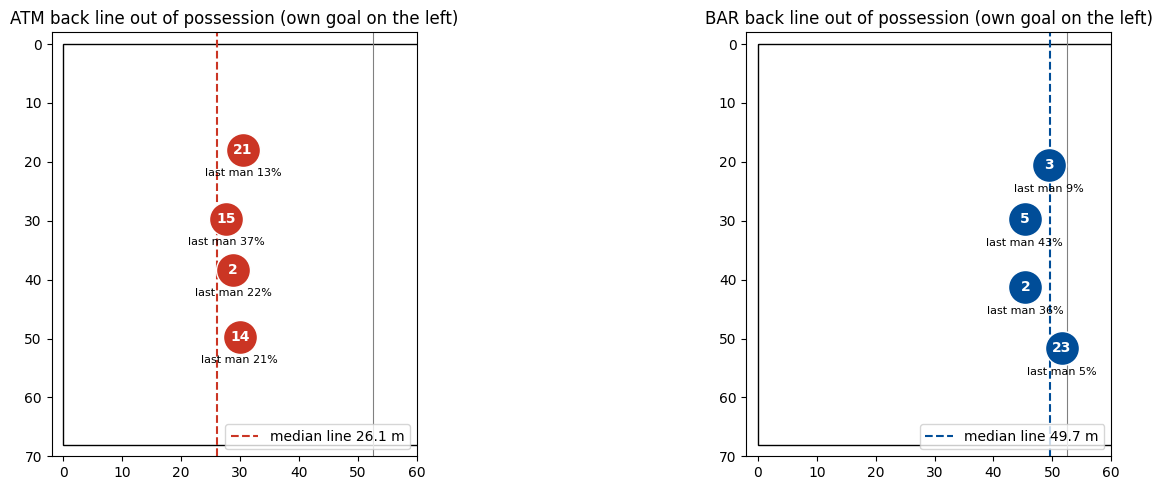

In [19]:
rows = []
for k, nm in TEAM_NAMES.items():
    t = live[(live.team == k) & (live.role == "player") & (live.possession_team == 1 - k)]
    deepest = t.loc[t.groupby("frame_idx").x_att.idxmin(), ["frame_idx", "track_id"]]
    lh = LH[(LH.team == k)].set_index("frame_idx").line_x
    for tid in DEF[k]:
        r = t[t.track_id == tid]
        rows.append({"team": nm, "defender": LABEL[tid], "frames": len(r),
                     "mean_depth_m": r.x_att.mean(), "mean_width_pos_m": r.y_att.mean(),
                     "vs_line_m": (r.x_att.values - lh.reindex(r.frame_idx).values).__array__().astype(float),
                     "last_man_share": (deepest.track_id == tid).sum() / max(len(deepest), 1)})
DT = pd.DataFrame(rows)
DT["vs_line_m"] = DT.vs_line_m.map(lambda a: float(np.nanmedian(a)) if len(a) else np.nan)
print(DT.round(2).to_string(index=False))

fig, axs = plt.subplots(1, len(TEAM_NAMES), figsize=(8 * len(TEAM_NAMES), 5))
for ax, (k, nm) in zip(np.atleast_1d(axs), TEAM_NAMES.items()):
    ax.add_patch(Rectangle((0, 0), L, W, fill=False)); ax.axvline(52.5, color="grey", lw=0.8)
    d = DT[DT.team == nm]
    med = oop[oop.team_name == nm].line_x.median()
    ax.axvline(med, color=RGB.get(nm), ls="--", lw=1.5, label=f"median line {med:.1f} m")
    for _, r in d.iterrows():
        tid = [t for t in DEF[k] if LABEL[t] == r.defender][0]
        ax.scatter(r.mean_depth_m, r.mean_width_pos_m, s=600, color=RGB.get(nm), edgecolor="white", zorder=3)
        ax.text(r.mean_depth_m, r.mean_width_pos_m, str(NUM.get(tid, "")), color="white", ha="center", va="center", weight="bold", zorder=4)
        ax.text(r.mean_depth_m, r.mean_width_pos_m + 4.5, f"last man {r.last_man_share:.0%}", ha="center", fontsize=8)
    ax.set_xlim(-2, 60); ax.set_ylim(W + 2, -2); ax.set_aspect("equal"); ax.legend(loc="lower right")
    ax.set_title(f"{nm} back line out of possession (own goal on the left)")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "back_line_defenders.png"), dpi=110); plt.show()

## 7. Moments for clips (chosen automatically)
Per team: highest line, deepest line, biggest drop, biggest step-up, and a typical high-block moment.

In [20]:
MOMENTS = []
for k, nm in TEAM_NAMES.items():
    o = oop[oop.team == k].dropna(subset=["line_x_smooth"])
    if len(o) == 0:
        continue
    hi_, lo_ = o.loc[o.line_x_smooth.idxmax()], o.loc[o.line_x_smooth.idxmin()]
    MOMENTS.append({"team": k, "team_name": nm, "kind": "highest_line", "start": int(hi_.frame_idx), "end": int(hi_.frame_idx),
                    "note": f"line {hi_.line_x_smooth:.1f} m from goal"})
    MOMENTS.append({"team": k, "team_name": nm, "kind": "deepest_line", "start": int(lo_.frame_idx), "end": int(lo_.frame_idx),
                    "note": f"line {lo_.line_x_smooth:.1f} m from goal"})
    hb = o[o.block == "high"]
    if len(hb):
        r = hb.iloc[(hb.line_x_smooth - hb.line_x_smooth.median()).abs().argsort().iloc[0]]
        MOMENTS.append({"team": k, "team_name": nm, "kind": "typical_high_block", "start": int(r.frame_idx), "end": int(r.frame_idx),
                        "note": f"line {r.line_x_smooth:.1f} m (team median in high block)"})
    if len(EV):
        for kd in ("drop", "step_up"):
            e = EV[(EV.team == k) & (EV.kind == kd)]
            if len(e):
                e = e.loc[e.change_m.abs().idxmax()]
                MOMENTS.append({"team": k, "team_name": nm, "kind": f"biggest_{kd}", "start": int(e.start), "end": int(e.end),
                                "note": f"{e.from_m} -> {e.to_m} m in {EVENT_WINDOW_S:.0f} s ({e.cause.replace('_', ' ')})"})
for m in MOMENTS:
    print(f"  {m['team_name']} {m['kind']:<20} {mmss(m['start'])}  {m['note']}")

  ATM highest_line         46:25.7  line 94.6 m from goal
  ATM deepest_line         06:41.1  line 3.2 m from goal
  ATM typical_high_block   18:50.6  line 47.8 m (team median in high block)
  ATM biggest_drop         09:54.3  31.8 -> 17.2 m in 2 s (without ball)
  ATM biggest_step_up      17:11.4  46.5 -> 60.6 m in 2 s (without ball)
  BAR highest_line         09:37.0  line 89.0 m from goal
  BAR deepest_line         39:12.3  line 6.1 m from goal
  BAR typical_high_block   14:52.6  line 57.7 m (team median in high block)
  BAR biggest_drop         39:06.0  30.6 -> 15.7 m in 2 s (without ball)
  BAR biggest_step_up      07:24.1  29.7 -> 45.4 m in 2 s (with ball)


## 8. Real match clips: line + offside line on the grass, back line highlighted, live graph, mini-pitch

In [ ]:
def _load_pickle(p):
    class _C(pickle.Unpickler):
        def find_class(self, m, n):
            return super().find_class(m.replace("numpy._core", "numpy.core", 1) if m.startswith("numpy._core") else m, n)
    b = open(p, "rb").read()
    try:
        return pickle.loads(b)
    except ModuleNotFoundError:
        return _C(io.BytesIO(b)).load()


def pitch_line_img(x_pitch, Hinv, Wv, Hv):
    pts = np.stack([np.full(35, x_pitch), np.linspace(0, W, 35)], 1) * PX_PER_METER
    ip = cv2.perspectiveTransform(pts[None].astype(np.float32), Hinv).reshape(-1, 2)
    ok = (ip[:, 0] > -Wv) & (ip[:, 0] < 2 * Wv) & (ip[:, 1] > -Hv) & (ip[:, 1] < 2 * Hv)
    return ip[ok].astype(np.int32)


def render_clip(m, HC, cap, fps_v):
    """Back line drawn as a line THROUGH the defenders' feet (left -> right), the last defender marked, and a
    dashed straight line across the pitch at the last defender's depth (= the line height / offside line)."""
    k, nm = m["team"], m["team_name"]
    s0, s1 = max(0, int(m["start"] - CLIP_PRE_S * FPS)), min(N_FRAMES - 1, int(m["end"] + CLIP_POST_S * FPS))
    rows = {f: g for f, g in pf[(pf.frame_idx >= s0) & (pf.frame_idx <= s1)].groupby("frame_idx")}
    lh = LH[(LH.team == k)].set_index("frame_idx")
    series = lh.line_x_smooth.reindex(range(s0, s1 + 1))
    cap.set(cv2.CAP_PROP_POS_FRAMES, s0)
    Wv, Hv = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)); sc = Hv / 1080
    path = os.path.join(CLIP_DIR, f"{nm}_{m['kind']}_{m['start']}.mp4")
    out = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*"mp4v"), fps_v, (Wv, Hv))
    col = TEAM_COLORS.get(nm, (0, 0, 255))
    gw, gh = int(360 * sc), int(120 * sc); gx, gy = Wv - gw - int(15 * sc), int(55 * sc)
    mw, mh = int(315 * sc), int(204 * sc); msc = mw / L
    for f in range(s0, s1 + 1):
        ok, img = cap.read()
        if not ok:
            break
        H = HC[f] if isinstance(HC, list) and f < len(HC) else None
        Hinv = np.linalg.inv(np.asarray(H, np.float64)) if H is not None else None
        g = rows.get(f)
        lx = lh.line_x.get(f, np.nan)                                     # last defender, this frame
        defs = None
        if g is not None:
            defs = g[g.track_id.isin(DEF[k]) & g.pitch_x.notna()].copy()
            defs["xa"] = along_x(defs.pitch_x.values, k)
            defs["ya"] = along_y(defs.pitch_y.values, k)
            defs = defs.sort_values("ya")
        last_id = int(defs.loc[defs.xa.idxmin(), "track_id"]) if defs is not None and len(defs) else None
        if Hinv is not None and np.isfinite(lx):                         # straight dashed line at the last defender
            q_ = pitch_line_img(to_pitch_x(lx, k), Hinv, Wv, Hv)
            for a_, b_ in zip(q_[::2], q_[1::2]):
                cv2.line(img, tuple(map(int, a_)), tuple(map(int, b_)), (0, 255, 255), max(1, int(2 * sc)), cv2.LINE_AA)
        if defs is not None and len(defs) >= 2:                          # line through the defenders' feet
            pts = np.stack([((defs.x1 + defs.x2) / 2).values, defs.y2.values], 1).astype(np.int32)
            cv2.polylines(img, [pts], False, (20, 20, 20), max(4, int(7 * sc)), cv2.LINE_AA)
            cv2.polylines(img, [pts], False, col, max(2, int(4 * sc)), cv2.LINE_AA)
        if g is not None:
            for t in g.itertuples():
                fx, fy = int((t.x1 + t.x2) / 2), int(t.y2)
                is_def = t.track_id in DEF[k]
                mine = (not pd.isna(t.team)) and int(t.team) == k
                c_ = col if mine else ((200, 200, 200) if t.role != "referee" else (30, 30, 30))
                rx = int(max((t.x2 - t.x1) * 0.6, 8 * sc))
                cv2.ellipse(img, (fx, fy), (rx, max(3, rx // 3)), 0, 0, 360, c_, int((4 if is_def else 2) * sc) or 1, cv2.LINE_AA)
                if t.track_id == last_id:                                  # the last defender
                    cv2.ellipse(img, (fx, fy), (rx + int(6 * sc), max(3, rx // 3) + int(4 * sc)), 0, 0, 360,
                                (0, 255, 255), max(2, int(3 * sc)), cv2.LINE_AA)
                if NUM.get(t.track_id) is not None:
                    tx = str(NUM[t.track_id]); (tw, th), _ = cv2.getTextSize(tx, cv2.FONT_HERSHEY_SIMPLEX, 0.5 * sc, 1)
                    cv2.rectangle(img, (fx - tw // 2 - 3, int(t.y1) - th - 9), (fx + tw // 2 + 3, int(t.y1) - 3), c_, -1)
                    cv2.putText(img, tx, (fx - tw // 2, int(t.y1) - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5 * sc, (255, 255, 255), max(1, int(sc)), cv2.LINE_AA)
            if last_id is not None and np.isfinite(lx):                    # label at the last defender
                r_ = g[g.track_id == last_id].iloc[0]
                txt = f"last defender #{NUM.get(last_id, '')}: {lx:.1f} m from goal"
                (tw, th), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, 0.6 * sc, max(1, int(2 * sc)))
                org = (int((r_.x1 + r_.x2) / 2) - tw // 2, int(r_.y2) + int(38 * sc))
                org = (min(max(org[0], 6), Wv - tw - 6), min(org[1], Hv - int(10 * sc)))
                cv2.rectangle(img, (org[0] - 6, org[1] - th - 7), (org[0] + tw + 6, org[1] + 7), (20, 20, 20), -1)
                cv2.putText(img, txt, org, cv2.FONT_HERSHEY_SIMPLEX, 0.6 * sc, (0, 255, 255), max(1, int(2 * sc)), cv2.LINE_AA)
            # mini pitch (defending team's own goal on the left): players, defenders' line, last-defender line
            x0, y0 = Wv - mw - int(15 * sc), Hv - mh - int(15 * sc)
            ov = img.copy(); cv2.rectangle(ov, (x0, y0), (x0 + mw, y0 + mh), (40, 110, 40), -1); cv2.addWeighted(ov, 0.85, img, 0.15, 0, img)
            cv2.rectangle(img, (x0, y0), (x0 + mw, y0 + mh), (235, 235, 235), 1)
            cv2.line(img, (x0 + mw // 2, y0), (x0 + mw // 2, y0 + mh), (235, 235, 235), 1)
            if np.isfinite(lx):
                xx = int(x0 + lx * msc)
                for yy in range(y0, y0 + mh, 8):
                    cv2.line(img, (xx, yy), (xx, min(yy + 4, y0 + mh)), (0, 255, 255), 1)
            if defs is not None and len(defs) >= 2:
                mp = np.stack([x0 + defs.xa.values * msc, y0 + defs.ya.values * msc], 1).astype(np.int32)
                cv2.polylines(img, [mp], False, col, 2, cv2.LINE_AA)
            for t in g.itertuples():
                if not np.isfinite(t.pitch_x) or t.role == "referee":
                    continue
                mine = (not pd.isna(t.team)) and int(t.team) == k
                cv2.circle(img, (int(x0 + along_x(t.pitch_x, k) * msc), int(y0 + along_y(t.pitch_y, k) * msc)),
                           max(3, int(5 * sc)), col if mine else (200, 200, 200), -1, cv2.LINE_AA)
            b_ = (bt.ball_pitch_x.get(f, np.nan), bt.ball_pitch_y.get(f, np.nan))
            if np.isfinite(b_[0]):
                cv2.circle(img, (int(x0 + along_x(b_[0], k) * msc), int(y0 + along_y(b_[1], k) * msc)), max(2, int(3 * sc)), (0, 255, 255), -1)
        # live graph: last-defender distance from goal, with cursor
        ov = img.copy(); cv2.rectangle(ov, (gx, gy), (gx + gw, gy + gh), (25, 25, 25), -1); cv2.addWeighted(ov, 0.75, img, 0.25, 0, img)
        vals = series.values; lo_, hi_ = 0.0, max(55.0, np.nanmax(vals) + 3 if np.isfinite(vals).any() else 55)
        pts = [(int(gx + i / max(len(vals) - 1, 1) * gw), int(gy + gh - (v - lo_) / (hi_ - lo_) * gh))
               for i, v in enumerate(vals) if np.isfinite(v)]
        if len(pts) >= 2:
            cv2.polylines(img, [np.array(pts, np.int32)], False, col, 2, cv2.LINE_AA)
        cx_ = int(gx + (f - s0) / max(s1 - s0, 1) * gw)
        cv2.line(img, (cx_, gy), (cx_, gy + gh), (255, 255, 255), 1)
        cv2.putText(img, "last defender, m from goal", (gx + 6, gy + int(18 * sc)), cv2.FONT_HERSHEY_SIMPLEX, 0.45 * sc, (230, 230, 230), 1, cv2.LINE_AA)
        ov = img.copy(); cv2.rectangle(ov, (0, 0), (Wv, int(40 * sc)), (20, 20, 20), -1); cv2.addWeighted(ov, 0.7, img, 0.3, 0, img)
        cv2.putText(img, f"{mmss(f)}  {nm} defensive line | {m['kind'].replace('_', ' ')} | {m['note']}", (int(12 * sc), int(27 * sc)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65 * sc, (255, 255, 255), max(1, int(sc)), cv2.LINE_AA)
        out.write(img)
    out.release()
    return path


CLIPS = []
if RENDER_CLIPS and MOMENTS:
    HC = _load_pickle(HOMOGRAPHY_PATH)
    cap = cv2.VideoCapture(VIDEO_PATH); assert cap.isOpened(), f"cannot open {VIDEO_PATH}"
    fps_v = cap.get(cv2.CAP_PROP_FPS) or FPS
    for m in MOMENTS:
        CLIPS.append({**m, "time": mmss(m["start"]), "clip": render_clip(m, HC, cap, fps_v)})
        print("  saved", CLIPS[-1]["clip"])
    cap.release()

  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\clips\ATM_highest_line_69643.mp4
  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\clips\ATM_deepest_line_10028.mp4
  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\clips\ATM_typical_high_block_28264.mp4
  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\clips\ATM_biggest_drop_14857.mp4
  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\clips\ATM_biggest_step_up_25786.mp4
  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\clips\BAR_highest_line_14425.mp4
  saved

## 9. 2D animations: top-down pitch + line-height timeline with a moving cursor
MP4 when ffmpeg is available to matplotlib, otherwise GIF.

In [ ]:
def animate(m):
    k, nm = m["team"], m["team_name"]
    s0, s1 = max(0, int(m["start"] - CLIP_PRE_S * FPS)), min(N_FRAMES - 1, int(m["end"] + CLIP_POST_S * FPS))
    frames = list(range(s0, s1 + 1, ANIM_STEP))
    rows = {f: g for f, g in live[(live.frame_idx >= s0) & (live.frame_idx <= s1)].groupby("frame_idx")}
    lh = LH.set_index(["team", "frame_idx"]).line_x_smooth
    fig = plt.figure(figsize=(11, 8.2)); gs = fig.add_gridspec(2, 1, height_ratios=[3, 1.2])
    ax, axt = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
    ax.add_patch(Rectangle((0, 0), L, W, fill=True, color="#3a7d44", zorder=0)); ax.add_patch(Rectangle((0, 0), L, W, fill=False, color="white"))
    ax.plot([52.5, 52.5], [0, W], color="white", lw=1)
    for x0 in (0, L - 16.5):
        ax.add_patch(Rectangle((x0, W / 2 - 20.16), 16.5, 40.32, fill=False, color="white", lw=1))
    ax.set_xlim(-3, L + 3); ax.set_ylim(W + 3, -3); ax.set_aspect("equal"); ax.axis("off")
    sc_ = {kk: ax.scatter([], [], s=180, color=RGB.get(TEAM_NAMES[kk]), edgecolor="white", zorder=3) for kk in TEAM_NAMES}
    txts = []
    ball = ax.scatter([], [], s=50, color="yellow", edgecolor="black", zorder=5)
    lines = {kk: ax.plot([], [], color=RGB.get(TEAM_NAMES[kk]), lw=2.5, ls="--", zorder=2)[0] for kk in TEAM_NAMES}
    ltxt = {kk: ax.text(0, -1.5, "", color=RGB.get(TEAM_NAMES[kk]), ha="center", fontsize=9, weight="bold") for kk in TEAM_NAMES}
    title = ax.set_title("")
    tt = np.arange(s0, s1 + 1)
    for kk in TEAM_NAMES:
        axt.plot(tt / FPS, [lh.get((kk, f), np.nan) for f in tt], color=RGB.get(TEAM_NAMES[kk]), lw=2, label=f"{TEAM_NAMES[kk]} line")
    cur = axt.axvline(s0 / FPS, color="black"); axt.set_ylabel("m from own goal"); axt.set_xlabel("match time (s)")
    axt.legend(loc="upper right", fontsize=8); axt.axvspan(m["start"] / FPS, m["end"] / FPS + 1e-3, color="orange", alpha=0.15)

    def upd(f):
        for t_ in txts: t_.remove()
        txts.clear()
        g = rows.get(f)
        for kk in TEAM_NAMES:
            if g is None:
                sc_[kk].set_offsets(np.empty((0, 2))); continue
            d = g[(g.team == kk).fillna(False)]
            sc_[kk].set_offsets(d[["pitch_x", "pitch_y"]].values)
            for r in d.itertuples():
                if NUM.get(r.track_id) is not None:
                    txts.append(ax.text(r.pitch_x, r.pitch_y, str(NUM[r.track_id]), color="white", fontsize=7,
                                        ha="center", va="center", zorder=4, weight="bold"))
            v = lh.get((kk, f), np.nan)
            if np.isfinite(v):
                xp = to_pitch_x(v, kk); lines[kk].set_data([xp, xp], [0, W]); ltxt[kk].set_position((xp, -1.5))
                ltxt[kk].set_text(f"{TEAM_NAMES[kk]} {v:.1f} m")
            else:
                lines[kk].set_data([], []); ltxt[kk].set_text("")
        b_ = (bt.ball_pitch_x.get(f, np.nan), bt.ball_pitch_y.get(f, np.nan))
        ball.set_offsets([b_] if np.isfinite(b_[0]) else np.empty((0, 2)))
        cur.set_xdata([f / FPS, f / FPS])
        title.set_text(f"{mmss(f)}   {nm} -- {m['kind'].replace('_', ' ')}: {m['note']}")
        return []

    an = animation.FuncAnimation(fig, upd, frames=frames, interval=1000 * ANIM_STEP / FPS, blit=False)
    if animation.writers.is_available("ffmpeg"):
        path = os.path.join(ANIM_DIR, f"{nm}_{m['kind']}_{m['start']}.mp4")
        an.save(path, writer=animation.FFMpegWriter(fps=FPS / ANIM_STEP, bitrate=2400))
    else:
        path = os.path.join(ANIM_DIR, f"{nm}_{m['kind']}_{m['start']}.gif")
        an.save(path, writer=animation.PillowWriter(fps=FPS / ANIM_STEP))
    plt.close(fig)
    return path


ANIMS = []
if RENDER_ANIMATIONS:
    for m in MOMENTS:
        ANIMS.append({**m, "animation": animate(m)})
        print("  saved", ANIMS[-1]["animation"])

  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\animations\ATM_highest_line_69643.gif
  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\animations\ATM_deepest_line_10028.gif
  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\animations\ATM_typical_high_block_28264.gif
  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\animations\ATM_biggest_drop_14857.gif
  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\animations\ATM_biggest_step_up_25786.gif
  saved C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line\animations\BAR_

## 10. Save tables + JSON report (for the LLM step)

In [ ]:
LH.to_parquet(os.path.join(OUT_DIR, "line_height_frames.parquet"), index=False)
if len(EV): EV.to_csv(os.path.join(OUT_DIR, "line_events.csv"), index=False, encoding="utf-8-sig")
DT.to_csv(os.path.join(OUT_DIR, "back_line_defenders.csv"), index=False, encoding="utf-8-sig")
report = {}
for k, nm in TEAM_NAMES.items():
    o, i = oop[oop.team == k], LH[(LH.team == k) & (LH.phase == "in_possession")]
    report[nm] = {
        "back_line": [LABEL[t] for t in DEF[k]],
        "out_of_possession": {"line_height_median_m": round(float(o.line_x.median()), 1) if len(o) else None,
                              "iqr_m": [round(float(o.line_x.quantile(.25)), 1), round(float(o.line_x.quantile(.75)), 1)] if len(o) else None,
                              "by_block_median_m": o.groupby("block").line_x.median().round(1).to_dict(),
                              "last_defender_median_m": round(float(o.last_defender_x.median()), 1) if len(o) else None,
                              "flatness_m": round(float(o.flatness.median()), 1) if len(o) else None,
                              "width_m": round(float(o.width.median()), 1) if len(o) else None,
                              "gk_to_line_m": round(float(o.gk_to_line_m.median()), 1) if len(o) else None,
                              "line_to_midfield_m": round(float(o.line_to_mid_m.median()), 1) if len(o) else None},
        "in_possession_line_height_median_m": round(float(i.line_x.median()), 1) if len(i) else None,
        "events": (EV[EV.team == k].groupby(["kind", "cause"]).size().unstack(fill_value=0).to_dict() if len(EV) else {}),
        "defenders": DT[DT.team == nm].drop(columns="team").round(2).to_dict("records"),
        "clips": [{k_: v for k_, v in c.items() if k_ != "team"} for c in CLIPS if c["team"] == k],
        "animations": [a["animation"] for a in ANIMS if a["team"] == k],
    }
with open(os.path.join(OUT_DIR, "defensive_line_report.json"), "w", encoding="utf-8") as fh:
    json.dump(report, fh, indent=1, ensure_ascii=False, default=lambda o: o.item() if hasattr(o, "item") else str(o))
print(f"Saved to {OUT_DIR}: line_height_frames, line_events, back_line_defenders, defensive_line_report.json, "
      f"figures, {len(CLIPS)} clips, {len(ANIMS)} animations")

Saved to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\defensive_line: line_height_frames, line_events, back_line_defenders, defensive_line_report.json, figures, 0 clips, 0 animations
